In [1]:
import scanpy as sc
import infercnvpy as cnv
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

from scipy import sparse as sp

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir



In [2]:
### read in raw data (before HVG selection)

### read in raw data (direct cellranger output, before any gene filtering)

adata_dir = large_data_dir + 'MPN_WTA/cr_BC007_1_1_sample_filtered_feature_bc_matrix.h5'
adata = sc.read_10x_h5(adata_dir)

adata_dir = large_data_dir + 'MPN_WTA/cr_BC007_1_2_sample_filtered_feature_bc_matrix.h5'
adata2 = sc.read_10x_h5(adata_dir)

adata = adata.concatenate(adata2, batch_key='expt', index_unique='-')

sc.pp.calculate_qc_metrics(adata, inplace = True)

min_counts = 500
min_genes = 250

sc.pp.filter_cells(adata,min_counts=min_counts)
sc.pp.filter_cells(adata,min_genes=min_genes)

### normalize and log-transform the data

sc.pp.normalize_total(adata, inplace = True)
sc.pp.log1p(adata)

/tmp/ipykernel_396638/669403079.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata.concatenate(adata2, batch_key='expt', index_unique='-')


In [3]:
processed_adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad')

### filter adata to match processed_adata
adata = adata[adata.obs_names.isin(processed_adata.obs_names)].copy()
adata.obs = adata.obs.loc[processed_adata.obs_names]
adata.obs['cell_type'] = processed_adata.obs['cell_type']
adata.obsm['X_umap'] = processed_adata.obsm['X_umap']
adata.obsm['genotypes'] = processed_adata.obsm['genotypes']
adata.obs['pheno_leiden'] = processed_adata.obs['pheno_leiden']
adata.uns = processed_adata.uns

### label clones in adata
adata.obs['clone'] = pd.read_csv('../../6_figure_MPN_AML_phylogeny/output/clone_assignments.csv',index_col=0)['clone']

chr_table = pd.read_csv('../data/hg38_gencode_v27.txt', sep='\t', header=None, on_bad_lines='skip', index_col=0)
chr_table.columns = ['chromosome', 'start','end']
adata.var = adata.var.merge(chr_table, left_index=True, right_index=True, how='left')

In [4]:
mat = sp.load_npz('../output/infercnv_gene_values.npz')

# convert to DataFrame (use adata indices/columns if available)
adata.layers['gene_values_cnv'] = pd.DataFrame(mat.toarray(), index=adata.obs_names, columns=adata.var_names)

In [5]:
palette = {'TP53_CALR_het' : 'lightcoral',
           'TP53_EZH2_CALR_mut' : 'mediumblue',
           'ZRSR2_CALR_mut' : 'palegreen'}


Chromosome: chr18, Number of genes: 248
Chromosome: chr5, Number of genes: 768
Chromosome: chr13, Number of genes: 290
Chromosome: chr19, Number of genes: 1260
Chromosome: chr17, Number of genes: 1032


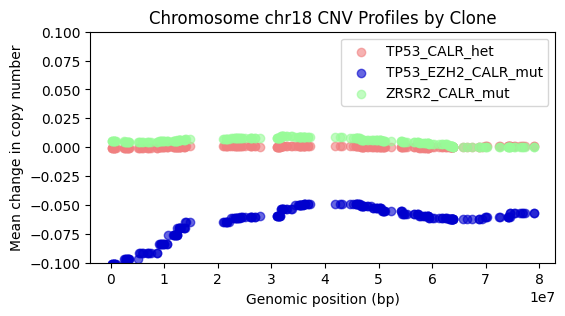

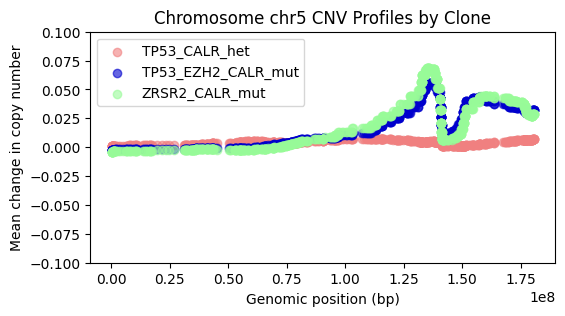

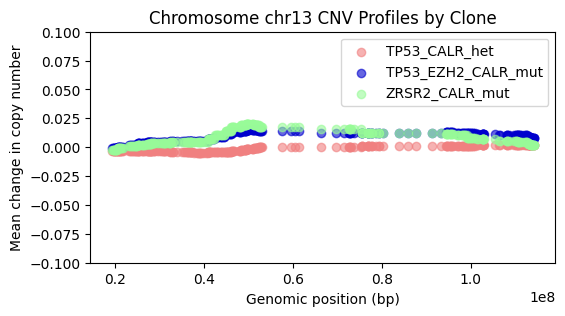

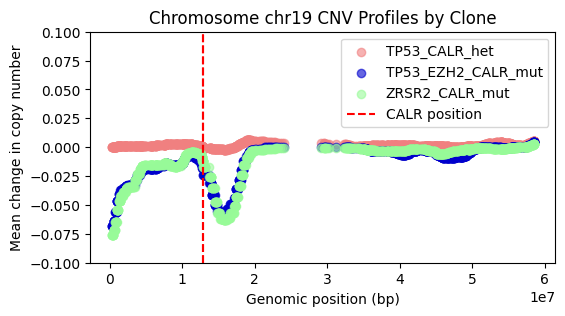

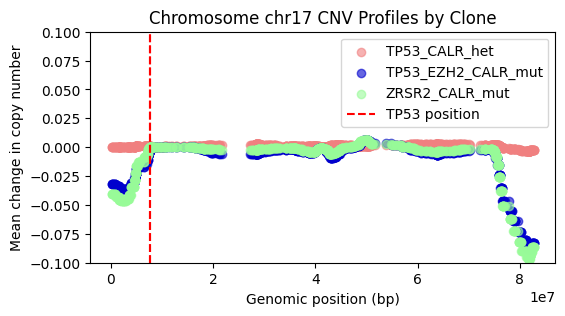

In [6]:
chr_means_dict = {}

for chr in ['chr18','chr5','chr13','chr19','chr17']:
    genes = adata.var.loc[adata.var['chromosome'] == chr]
    print(f"Chromosome: {chr}, Number of genes: {genes.shape[0]}")
    chr_means_dict[chr] = pd.DataFrame(genes[['start','end']], index=genes.index)

    fig,ax = plt.subplots(figsize=(6,3))

    for clone in palette.keys():
        # Filter cells for the specific clone
        clone_mask = (adata.obs['clone'] == clone)

        # Get gene indices for chr genes
        chr_gene_indices = adata.var_names.isin(genes.index)

        # Extract CNV values for the specific clone and chr19 genes
        chr_cnv_values = adata.layers['gene_values_cnv'][clone_mask, :][:, chr_gene_indices]

        # Calculate mean for each gene
        chr_means = chr_cnv_values.mean(axis=0)

        # Create a series with gene names as index
        chr_gene_means = pd.DataFrame(chr_means, index=genes.index, columns = ['cnv_mean'])
        chr_gene_means = chr_gene_means.merge(adata.var[['chromosome', 'start', 'end']], left_index=True, right_index=True)

        ax.scatter(x=chr_gene_means['start'], y=chr_gene_means['cnv_mean'], label=clone, alpha=0.6, c=palette[clone])
        chr_means_dict[chr] = pd.merge(chr_means_dict[chr], chr_gene_means[['cnv_mean']], left_index=True, right_index=True, how='left', suffixes=('', f'_{clone}'))
    
    for special_gene in ['CALR','TP53']:
        if special_gene in genes.index:
            ax.axvline(x=chr_gene_means.loc[special_gene, 'start'], color='red', linestyle='--', label=f'{special_gene} position')
            ax.axvline(x=chr_gene_means.loc[special_gene, 'end'], color='red', linestyle='--')

    ax.set_title(f'Chromosome {chr} CNV Profiles by Clone')
    ax.set_ylim(-0.1, 0.1)
    ax.legend()

    ax.set_xlabel('Genomic position (bp)')
    ax.set_ylabel('Mean change in copy number')
    plt.savefig(f'../plots/infercnv_{chr}_clone_means.pdf', bbox_inches='tight')
